<a href="https://colab.research.google.com/github/266q1a44221-maker/2D-game-transformation-engine/blob/main/2D_game_transformation_engine_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

           2D GAME TRANSFORMATION ENGINE

INPUT VALUES
------------------------------------------------------------
Rotation angle : 30 degrees
Scale X        : 2.0
Scale Y        : 2.0
Translation X  : 3.0
Translation Y  : 2.0

SCALING MATRIX (S)
[[2. 0. 0.]
 [0. 2. 0.]
 [0. 0. 1.]]

ROTATION MATRIX (R)
[[ 0.8660254 -0.5        0.       ]
 [ 0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]

TRANSLATION MATRIX (T)
[[1. 0. 3.]
 [0. 1. 2.]
 [0. 0. 1.]]

STEP-BY-STEP TRANSFORMATION

1. Original Triangle:
[[0. 2. 0.]
 [0. 0. 2.]
 [1. 1. 1.]]

2. After Scaling:
[[0. 4. 0.]
 [0. 0. 4.]
 [1. 1. 1.]]

3. After Rotation:
[[ 0.          3.46410162 -2.        ]
 [ 0.          2.          3.46410162]
 [ 1.          1.          1.        ]]

4. After Translation:
[[3.         6.46410162 1.        ]
 [2.         4.         5.46410162]
 [1.         1.         1.        ]]

TOTAL TRANSFORMATION MATRIX
[[ 1.73205081 -1.          3.        ]
 [ 1.          1.73205081  2.        ]
 [

,Vertex,Original X,Original Y,Final X,Final Y
0,A,0.0,0.0,3.000,2.000
1,B,2.0,0.0,6.464,4.000
2,C,0.0,2.0,1.000,5.464


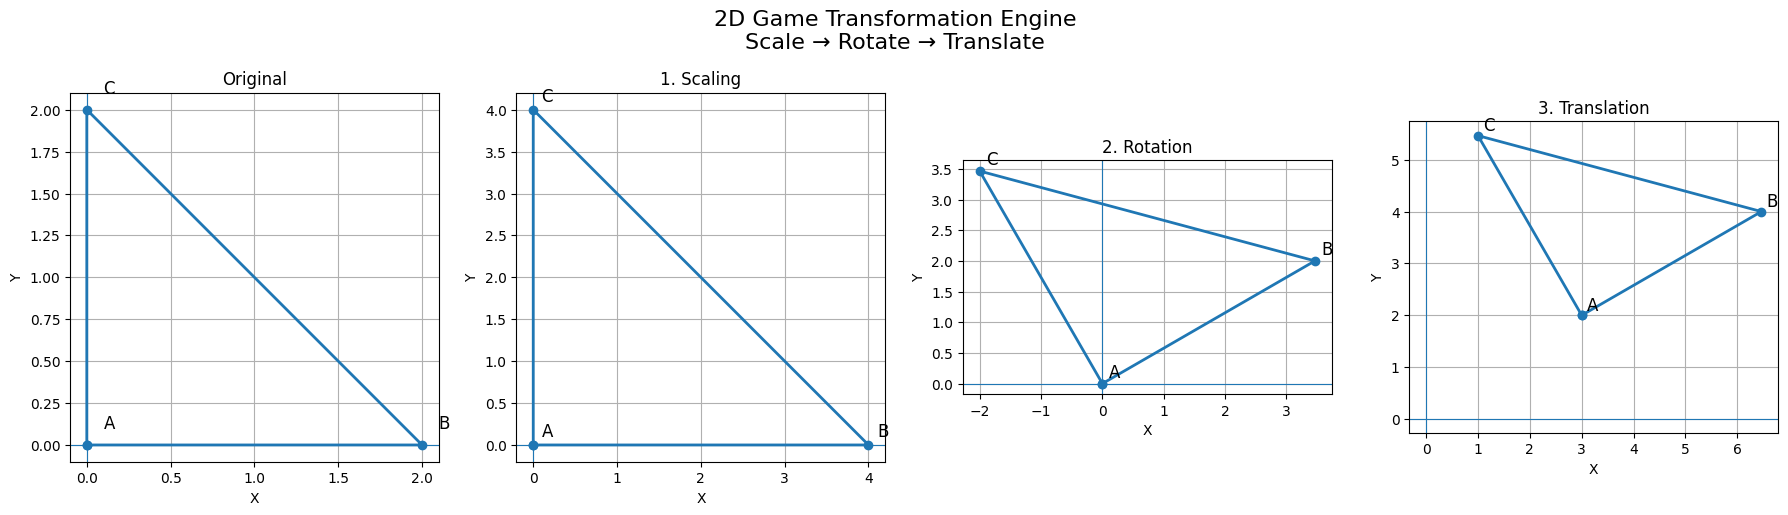


BENCHMARK TEST

Small Movement
Angle: 0 | Scale: 1 | Translation: (2, 1)
Final Coordinates:
[[2. 4. 2.]
 [1. 1. 3.]]

Rotation
Angle: 45 | Scale: 1 | Translation: (0, 0)
Final Coordinates:
[[ 0.    1.41 -1.41]
 [ 0.    1.41  1.41]]

Scaling
Angle: 0 | Scale: 2 | Translation: (0, 0)
Final Coordinates:
[[0. 4. 0.]
 [0. 0. 4.]]

Complete
Angle: 30 | Scale: 2 | Translation: (3, 2)
Final Coordinates:
[[3.   6.46 1.  ]
 [2.   4.   5.46]]

PROJECT COMPLETED SUCCESSFULLY!


In [ ]:

# ============================================================
#        2D GAME TRANSFORMATION ENGINE (F3)
#        B.Tech Mathematics Mini Project
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. USER INPUTS
# ------------------------------------------------------------
theta = 30       # Rotation angle in degrees
sx = 2.0         # Scaling in X direction
sy = 2.0         # Scaling in Y direction
tx = 3.0         # Translation in X direction
ty = 2.0         # Translation in Y direction

print("=" * 60)
print("           2D GAME TRANSFORMATION ENGINE")
print("=" * 60)

print("\nINPUT VALUES")
print("-" * 60)
print("Rotation angle :", theta, "degrees")
print("Scale X        :", sx)
print("Scale Y        :", sy)
print("Translation X  :", tx)
print("Translation Y  :", ty)

# ------------------------------------------------------------
# 2. ORIGINAL TRIANGLE
# ------------------------------------------------------------
# Triangle vertices:
# A = (0,0), B = (2,0), C = (0,2)
#
# Homogeneous coordinates are used so that translation
# can also be represented as a matrix.

triangle = np.array([
    [0, 2, 0],
    [0, 0, 2],
    [1, 1, 1]
], dtype=float)

# ------------------------------------------------------------
# 3. TRANSFORMATION MATRICES
# ------------------------------------------------------------

angle = np.radians(theta)

# Scaling Matrix
S = np.array([
    [sx, 0,  0],
    [0,  sy, 0],
    [0,  0,  1]
])

# Rotation Matrix
R = np.array([
    [np.cos(angle), -np.sin(angle), 0],
    [np.sin(angle),  np.cos(angle), 0],
    [0,              0,             1]
])

# Translation Matrix
T = np.array([
    [1, 0, tx],
    [0, 1, ty],
    [0, 0, 1]
])

print("\nSCALING MATRIX (S)")
print(S)

print("\nROTATION MATRIX (R)")
print(R)

print("\nTRANSLATION MATRIX (T)")
print(T)

# ------------------------------------------------------------
# 4. STEP-BY-STEP TRANSFORMATION
# ------------------------------------------------------------

# Step 1: Scale
triangle_scaled = S @ triangle

# Step 2: Rotate
triangle_rotated = R @ triangle_scaled

# Step 3: Translate
triangle_final = T @ triangle_rotated

print("\n" + "=" * 60)
print("STEP-BY-STEP TRANSFORMATION")
print("=" * 60)

print("\n1. Original Triangle:")
print(triangle)

print("\n2. After Scaling:")
print(triangle_scaled)

print("\n3. After Rotation:")
print(triangle_rotated)

print("\n4. After Translation:")
print(triangle_final)

# ------------------------------------------------------------
# 5. TOTAL TRANSFORMATION MATRIX
# ------------------------------------------------------------
# Required composition:
# Total = Translation × Rotation × Scaling

Total = T @ R @ S

print("\n" + "=" * 60)
print("TOTAL TRANSFORMATION MATRIX")
print("=" * 60)

print(Total)

# Apply total matrix directly
direct_result = Total @ triangle

print("\nFinal result using Total Matrix:")
print(direct_result)

# ------------------------------------------------------------
# 6. VERIFY THE RESULT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("VERIFICATION")
print("=" * 60)

if np.allclose(triangle_final, direct_result):
    print("SUCCESS: Step-by-step and combined results are equal.")
else:
    print("Results are different.")

# ------------------------------------------------------------
# 7. FINAL COORDINATE TABLE
# ------------------------------------------------------------

vertices = ["A", "B", "C"]

result_table = pd.DataFrame({
    "Vertex": vertices,
    "Original X": triangle[0],
    "Original Y": triangle[1],
    "Final X": triangle_final[0],
    "Final Y": triangle_final[1]
})

print("\n" + "=" * 60)
print("FINAL COORDINATES")
print("=" * 60)

display(result_table.round(3))

# ------------------------------------------------------------
# 8. VISUALIZATION
# ------------------------------------------------------------

def draw_triangle(ax, points, title):
    # Close triangle by repeating first point
    x = np.append(points[0], points[0][0])
    y = np.append(points[1], points[1][0])

    ax.plot(x, y, marker="o", linewidth=2)

    # Label vertices
    for i, label in enumerate(["A", "B", "C"]):
        ax.text(
            points[0][i] + 0.1,
            points[1][i] + 0.1,
            label,
            fontsize=12
        )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)
    ax.grid(True)
    ax.set_aspect("equal")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title)

# ------------------------------------------------------------
# 9. PLOT ALL TRANSFORMATION STEPS
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

draw_triangle(
    axes[0],
    triangle,
    "Original"
)

draw_triangle(
    axes[1],
    triangle_scaled,
    "1. Scaling"
)

draw_triangle(
    axes[2],
    triangle_rotated,
    "2. Rotation"
)

draw_triangle(
    axes[3],
    triangle_final,
    "3. Translation"
)

plt.suptitle(
    "2D Game Transformation Engine\n"
    "Scale → Rotate → Translate",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. SMALL BENCHMARK TEST
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("BENCHMARK TEST")
print("=" * 60)

tests = [
    ("Small Movement", 0, 1, 2, 1),
    ("Rotation", 45, 1, 0, 0),
    ("Scaling", 0, 2, 0, 0),
    ("Complete", 30, 2, 3, 2)
]

for name, angle_deg, scale, move_x, move_y in tests:

    a = np.radians(angle_deg)

    S_test = np.array([
        [scale, 0, 0],
        [0, scale, 0],
        [0, 0, 1]
    ])

    R_test = np.array([
        [np.cos(a), -np.sin(a), 0],
        [np.sin(a),  np.cos(a), 0],
        [0, 0, 1]
    ])

    T_test = np.array([
        [1, 0, move_x],
        [0, 1, move_y],
        [0, 0, 1]
    ])

    total_test = T_test @ R_test @ S_test
    result_test = total_test @ triangle

    print(f"\n{name}")
    print("Angle:", angle_deg,
          "| Scale:", scale,
          "| Translation:", (move_x, move_y))
    print("Final Coordinates:")
    print(np.round(result_test[:2], 2))

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)